# 🧮 Interactive Simulator: The Math of the Camera

### Welcome, Physicists!
In photography, art is ruled by algebra. When you change your lens opening (Aperture) to let in more light, you accidentally change the geometry of your focus (Depth of Field). 

In this notebook, we will use Python to calculate exactly how light and geometry interact. 

**Teacher Instructions:** Run the cells below to visualize the Reciprocity Law ($E = I \times t$) and calculate the Hyperfocal Distance for landscape photography.

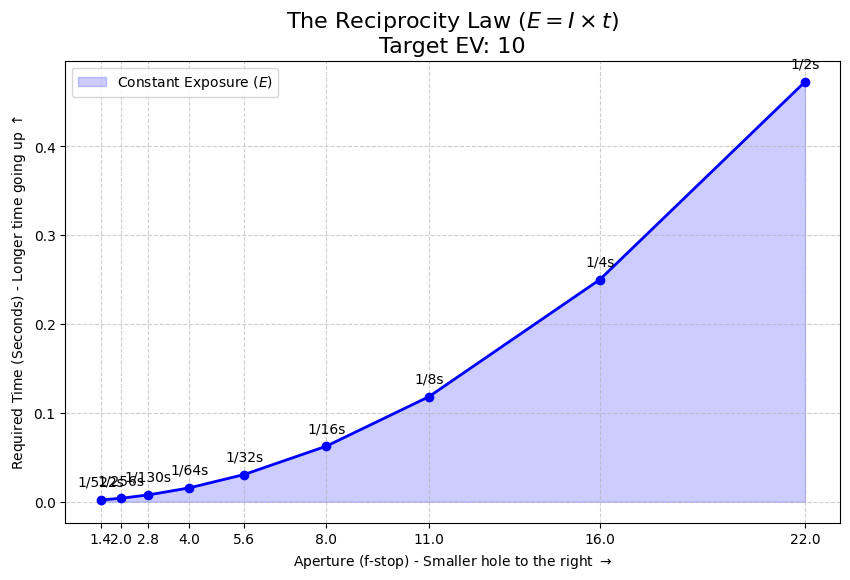

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reciprocity_curve(target_exposure_value=10):
    """
    Plots the reciprocal relationship between Aperture (I) and Time (t).
    Calculates the required shutter speed for standard f-stops to maintain constant Exposure (E).
    """
    # Standard full-stop aperture values (f-numbers)
    f_stops = np.array([1.4, 2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0, 22.0])
    
    # In physics, Intensity (I) is inversely proportional to the SQUARE of the f-stop.
    # We calculate the required shutter speed (t) to keep E constant.
    # Formula derived from Exposure Value (EV) math: t = (N^2) / (2^EV)
    shutter_speeds = (f_stops**2) / (2**target_exposure_value)
    
    plt.figure(figsize=(10, 6))
    plt.plot(f_stops, shutter_speeds, marker='o', linestyle='-', color='b', linewidth=2)
    
    # Fill the area to represent the "Bucket" of light (Constant Exposure)
    plt.fill_between(f_stops, shutter_speeds, alpha=0.2, color='blue', label="Constant Exposure ($E$)")
    
    # Formatting
    plt.title(f"The Reciprocity Law ($E = I \\times t$)\nTarget EV: {target_exposure_value}", fontsize=16)
    plt.xlabel("Aperture (f-stop) - Smaller hole to the right $\\rightarrow$")
    plt.ylabel("Required Time (Seconds) - Longer time going up $\\uparrow$")
    
    # Annotate standard pairs
    for i, txt in enumerate(shutter_speeds):
        # Format fractions for readability if speed is less than 1 second
        if txt < 1:
            label = f"1/{int(1/txt)}s"
        else:
            label = f"{txt:.1f}s"
        plt.annotate(label, (f_stops[i], shutter_speeds[i]), textcoords="offset points", xytext=(0,10), ha='center')

    plt.xticks(f_stops)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# Run the exposure simulator!
plot_reciprocity_curve(target_exposure_value=10)

# 📉 The Physics of Reciprocity Failure (The Schwarzschild Effect)

### Introduction
In ideal conditions, photographic exposure follows the **Reciprocity Law**:
$$E = I \times t$$
Where:
* $E$ is Exposure
* $I$ is Intensity of Light (controlled by Aperture)
* $t$ is Time (Shutter Speed)

However, when exposure times exceed 1 second, film emulsions lose sensitivity. This is known as the **Schwarzschild Effect**. The silver halide crystals require a higher density of photons arriving simultaneously to form a stable latent image.

### The Formula
A common correction formula for long exposures is:
$$t_c = t_m^{p}$$
Where:
* $t_c$ = Corrected time (what you set on the camera)
* $t_m$ = Measured time (what your light meter says)
* $p$ = Schwarzschild factor (usually between 1.3 and 1.5 depending on the film)

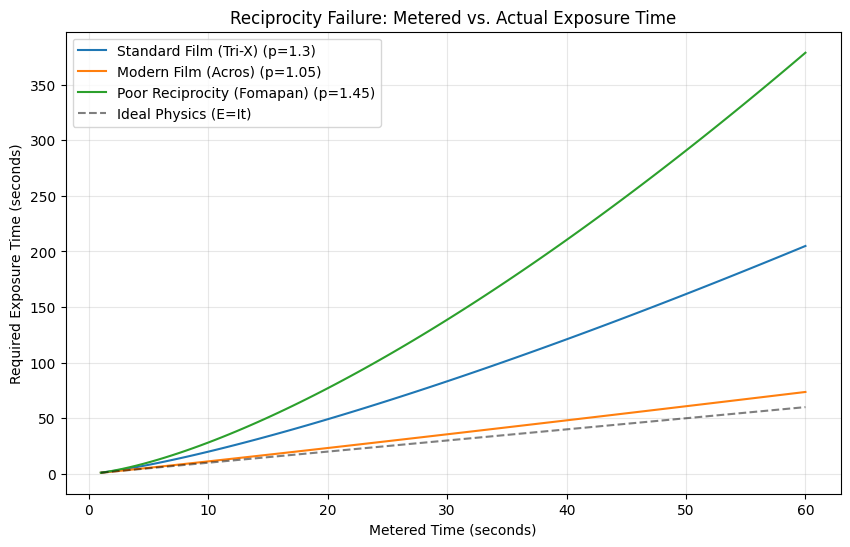

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Common Schwarzschild factors for different films:
# Kodak Tri-X 400: ~1.3
# Ilford HP5+: ~1.31
# Fujifilm Acros 100: ~1.05 (Very resistant to failure!)

film_types = {
    "Standard Film (Tri-X)": 1.3,
    "Modern Film (Acros)": 1.05,
    "Poor Reciprocity (Fomapan)": 1.45
}

# Generate measured times from 1 second to 60 seconds
measured_times = np.linspace(1, 60, 100)

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

for film, p_factor in film_types.items():
    # Calculate corrected time: t_corrected = t_measured ^ p
    corrected_times = measured_times ** p_factor
    plt.plot(measured_times, corrected_times, label=f"{film} (p={p_factor})")

# Add the "Ideal" line (No failure)
plt.plot(measured_times, measured_times, 'k--', label="Ideal Physics (E=It)", alpha=0.5)

plt.title("Reciprocity Failure: Metered vs. Actual Exposure Time")
plt.xlabel("Metered Time (seconds)")
plt.ylabel("Required Exposure Time (seconds)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 🔍 Analysis: The Exposure Curve
Look at the graph above. As you move to the right, your lens hole gets smaller (f/22). To keep the bucket of light filled perfectly, the required time shoots up dramatically!

If your exposure requires more than 1 second, the silver halide crystals on the film might start to fail (The Schwarzschild Effect). 

---

### The Geometry of Focus: Calculating Hyperfocal Distance ($H$)
Now, let's look at the geometry. If you are shooting a landscape and want the mountains *and* the foreground flowers to be sharp, where do you focus? 

You must calculate the **Hyperfocal Distance**.
$$H = \frac{f^2}{N \cdot c}$$

--- LENS GEOMETRY REPORT ---
Lens: 28mm
Aperture: f/8.0
Circle of Confusion: 0.03mm
----------------------------
📍 HYPERFOCAL DISTANCE (H): 3.27 meters
If you set your lens focus ring to exactly 3.27 meters:
✅ Everything from 1.63 meters to INFINITY will be perfectly sharp!


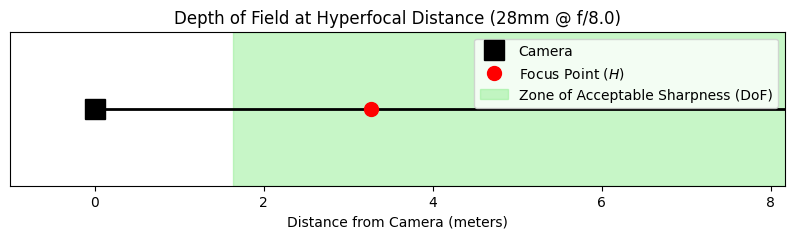

In [4]:
def calculate_hyperfocal(focal_length_mm, aperture_f, sensor_coc=0.03):
    """
    Calculates the Hyperfocal Distance and visualizes the Depth of Field.
    """
    f = focal_length_mm
    N = aperture_f
    c = sensor_coc
    
    # Calculate H in millimeters, then convert to meters
    H_mm = (f**2) / (N * c)
    H_m = H_mm / 1000
    
    # The rule of Hyperfocal Distance:
    # If you focus exactly at H, everything from (H/2) to Infinity is sharp.
    near_limit = H_m / 2
    
    print(f"--- LENS GEOMETRY REPORT ---")
    print(f"Lens: {f}mm")
    print(f"Aperture: f/{N}")
    print(f"Circle of Confusion: {c}mm")
    print(f"----------------------------")
    print(f"📍 HYPERFOCAL DISTANCE (H): {H_m:.2f} meters")
    print(f"If you set your lens focus ring to exactly {H_m:.2f} meters:")
    print(f"✅ Everything from {near_limit:.2f} meters to INFINITY will be perfectly sharp!")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.plot([0, H_m * 3], [0, 0], 'k-', lw=2) # Camera to Infinity axis
    
    # Draw the camera
    ax.plot(0, 0, 'ks', markersize=15, label="Camera")
    
    # Draw the focus point
    ax.plot(H_m, 0, 'ro', markersize=10, label="Focus Point ($H$)")
    
    # Highlight the sharp zone
    ax.axvspan(near_limit, H_m * 3, color='lightgreen', alpha=0.5, label="Zone of Acceptable Sharpness (DoF)")
    
    ax.set_yticks([])
    ax.set_xlabel("Distance from Camera (meters)")
    ax.set_xlim(-1, H_m * 2.5)
    ax.set_title(f"Depth of Field at Hyperfocal Distance ({f}mm @ f/{N})")
    ax.legend(loc="upper right")
    plt.show()

# Run the DoF Calculator! 
# Try changing the focal length (e.g., 28mm vs 200mm) or the aperture (e.g., 2.8 vs 16.0)
calculate_hyperfocal(focal_length_mm=28, aperture_f=8.0)

### 🧪 Analysis
Observe the graph above.
1. **The Ideal Line (Dotted):** If physics were perfect, a 30-second reading would need a 30-second exposure.
2. **Fomapan (Blue/Green):** At a metered 30 seconds, you actually need nearly **140 seconds** of exposure!
3. **Acros (Orange):** It stays almost linear. This makes it an engineering marvel for night photography.

**Assignment:**
Calculate the required exposure for **Ilford Delta 3200** (Factor 1.35) if your light meter reads **15 seconds**.

### 📝 The Artistic Choice
Notice what happens if you change the variables in the code above:
1. **Wide Lens (28mm) + Tiny Hole (f/16):** The Hyperfocal Distance is very close to the camera. Almost the entire world is in focus.
2. **Telephoto Lens (200mm) + Big Hole (f/2.8):** The Hyperfocal Distance is hundreds of meters away! It is mathematically impossible to keep a close subject and the background in focus at the same time.

By mastering these equations, you take complete control over the physics of the photograph.